In [2]:
%load_ext autoreload
%autoreload 2

import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import openpyxl
import re
import warnings
from src.config import DATA_RAW, DATA_PROCESSED
from IPython.display import display
from src.preprocessing import clean_sponsor_columns
from src.data_loader import load_raw, save_processed, load_processed
from src.preprocessing import clean_data, check_missing_values, check_duplicates, clean_sponsor_columns, clean_region_column
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
pd.options.display.float_format = '{:.2f}'.format

In [3]:
df = load_processed("cleaned_survey_data.csv")
df.head()

'cleaned_survey_data.csv' oxundu. Shape: (52, 48)


,Timestamp,Turan Tovuz PFK-nın oyunlarını hansı tezlikdə izləyirsiniz?,Hansı səbəbdən oyunları tez tez izləmirsiniz?,Oyunları əsasən necə izləyirsiniz?,Oyunları hansı səbəbdən stadionda izləmirsiniz?,Oyun barədə məlumatı haradan əldə etmisiniz?,Bileti haradan almısınız?,Stadiona getmək üçün hansı vasitədən istifadə etmisiniz?,Stadionda son izlədiyiniz oyunu sizinlə neçə nəfər gəlib?,"Stadionda son izlədiyiniz oyunu sizinlə gələnlərin arasında uşaq var idi? bir neçə uşaq gəlmişdirsə, sayı ""digər"" bölməsində qeyd edə bilərsiniz","Sizcə, oyuna ailənizlə gəlmək üçün şərait uyğundurmu?",Xahiş edirik stadiona gedərkən üzləşdiyiniz problemləri qeyd edin:,Xahiş edirik stadionda üzləşdiyiniz problemləri qeyd edin:,Xahiş edirik stadiondan çıxarkən üzləşdiyiniz problemləri qeyd edin:,Stadion ərazisində satışda olan qida və içkilər almısınızmı?,Oyun zamanı satışda olan qida və içkilərə ortalama nə qədər pul xərcləmisiniz? məbləğ(AZN),Satış məntəqələrinin əlçatan olması,Qida və içkilərin çeşidləri,Qida və içkilərin keyfiyyəti,Qida və içkilərin qiyməti,Stadion ərazisindəki fanşopdan klubun məhsullarını almısınızmı?,Oyun zamanı satışda olan klubun məhsullarına nə qədər pul xərcləmisiniz?,Satış məntəqələrinin əlçatan olması 2,Məhsulların çeşidləri,Məhsulların keyfiyyəti,Bilet alma prosesini necə qiymətləndirirsiniz?,Bilet yoxlayan əməkdaşların işini necə qiymətləndirirsiniz?,Təhlükəsizlik xidmətinin işini necə qiymətləndirirsiniz?,"Könüllülərin işini necə qiymətləndirirsiniz? (istiqamətin göstərilməsi, sualların cavablandırılması və s.)",Tribunaların təmizliyini necə qiymətləndirirsiniz?,Tualetlərin təmizliyini necə qiymətləndirirsiniz?,Stadionda olan ab-havanı necə qiymətləndirirsiniz?,Ümumi oyunun təşkilini necə qiymətləndirirsiniz?,Klubun faəliyyətini necə dəyərləndirirsiniz?,Sponsorun dəstəyini necə dəyərləndirirsiniz?,Stadionda neçə sponsor reklamı gördünüz?,Bunlar hansılardır?,"Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?","Son oyundakı təcrübənizə əsasən, dostlarınıza Turan Tovuz PFK-nın oyunlarını stadionda izləməyi tövsiyə edərsiniz?","Ad, soyad",Cins,Yaşınız,Məşğuliyyət,Ailə vəziyyəti,Turan Tovuz PFK-nın fəaliyyəti ilə bağlı məlumat almaq istəyirsinizmi?,Qeydlər,"Harada yaşayırsınız, oyunu izləməyə haradan gəlmisiniz? rayon/kəndin adını qeyd edin",Məhsulların qiyməti
0,2025-03-19 15:47:08.896,Hər oyununu izləyirəm,Qeyd olunmayıb,Stadionda baxıram,Qeyd olunmayıb,Sosial media kanallarından,Stadionun kassasından,Piyada,2,Xeyr,Bəli,Qarşı tribunanın üstünün bağlı olması,Heç bir problemlə üzləşmədim,Heç bir problemlə üzləşmədim,Bəli,1.00,10.00,5.00,5.00,5.00,Xeyr,NaN,NaN,NaN,NaN,10,7,10,9,10,10.00,10,6,10,10,1,HUNER GROUP,Bəli,Bəli,Tural İmanov,Kişi,37,İşləyirəm,Evli,Bəli,Şərh yoxdur,Tovuz şəhəri,NaN
1,2025-03-18 12:57:01.184,Hər oyununu izləyirəm,Qeyd olunmayıb,Stadionda baxıram,Qeyd olunmayıb,Şəhərdə yerləşən posterlərdən,Stadionun kassasından,Piyada,12,Xeyr,Bəli,Heç bir problemlə üzləşmədim,Heç bir problemlə üzləşmədim,Heç bir problemlə üzləşmədim,Bəli,1.00,10.00,10.00,10.00,10.00,Xeyr,NaN,NaN,NaN,NaN,10,10,10,10,10,10.00,10,10,10,10,3,"HUNER GROUP, Tovuz Su, FİF",Bəli,Bəli,Rüstəm Zeynalov,Kişi,42,İşsizəm,Evli,Bəli,Şərh yoxdur,Qeyd olunmayıb,NaN
2,2025-03-18 12:07:38.943,Hər oyununu izləyirəm,Qeyd olunmayıb,Stadionda baxıram,Qeyd olunmayıb,Tanışlardan,Dəvətnamə veriblər,Taksi,1,Bəli,Bəli,"Stadionun parkinqində yerin az olması, Heç bir...",Tütün məhsullarının istifadəsi. Smiçka çırtdam...,"Stadiondan çıxış zamanı sıxlıq olması, Heç bir...",Bəli,1.00,8.00,5.00,7.00,5.00,Bəli,10.00,8.00,5.00,8.00,10,10,10,10,10,5.00,10,10,8,10,3,"HUNER GROUP, Oyal, Böyük Qışlaq Su",Bəli,Bəli,Gülnarə Qədirova,Qadın,33,İşsizəm,Evli,Xeyr,Yaşasın Tovuz,Qeyd olunmayıb,NaN
3,2025-03-19 14:06:35.732,Hər oyununu izləyirəm,Qeyd olunmayıb,Stadionda baxıram,Qeyd olunmayıb,Sosial media kanallarından,Stadionun kassasından,İctimai nəqliyyat,8,Bəli,Bəli,Heç bir problemlə üzləşmədim,Heç bir problemlə üzləşmədim

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 48 columns):
 #   Column                                                                                                                                            Non-Null Count  Dtype         
---  ------                                                                                                                                            --------------  -----         
 0   Timestamp                                                                                                                                         52 non-null     datetime64[us]
 1   Turan Tovuz PFK-nın oyunlarını hansı tezlikdə izləyirsiniz?                                                                                       52 non-null     str           
 2   Hansı səbəbdən oyunları tez tez izləmirsiniz?                                                                                                     52 non-null     str          

In [5]:
rating_cols = {
    'Ümumi təşkilat': 'Ümumi oyunun təşkilini necə qiymətləndirirsiniz?',
    'Klub fəaliyyəti': 'Klubun faəliyyətini necə dəyərləndirirsiniz?',
    'Sponsor dəstəyi': 'Sponsorun dəstəyini necə dəyərləndirirsiniz?',
}


In [6]:
summary = df.groupby('Stadionda neçə sponsor reklamı gördünüz?')[list(rating_cols.values())].mean().round(2)
summary.columns = list(rating_cols.keys())
summary['n (sayı)'] = df.groupby('Stadionda neçə sponsor reklamı gördünüz?').size()
print('==== Sponsor reklamlarının sayına görə orta reytinqlər ====')
print(summary)

==== Sponsor reklamlarının sayına görə orta reytinqlər ====
                                          Ümumi təşkilat  Klub fəaliyyəti  \
Stadionda neçə sponsor reklamı gördünüz?                                    
0                                                   7.27             6.82   
1                                                   8.73             8.60   
2                                                   8.25             9.00   
3                                                  10.00             9.33   

                                          Sponsor dəstəyi  n (sayı)  
Stadionda neçə sponsor reklamı gördünüz?                             
0                                                    8.45        11  
1                                                    9.47        30  
2                                                    9.88         8  
3                                                   10.00         3  


In [7]:
exploded = df['Bunlar hansılardır?'].dropna().str.split(', ').explode()
sponsor_freq = exploded.value_counts()
print("=== Sponsorların yadda qalma tezliyi ===")
print(sponsor_freq)
print()

=== Sponsorların yadda qalma tezliyi ===
Bunlar hansılardır?
HUNER GROUP            40
Tovuz Su                6
Böyük Qışlaq Su         2
Tovuz Mall              2
FİF                     1
Oyal                    1
Ada Store               1
Az Group                1
Kapital Bank Plakat     1
Name: count, dtype: int64



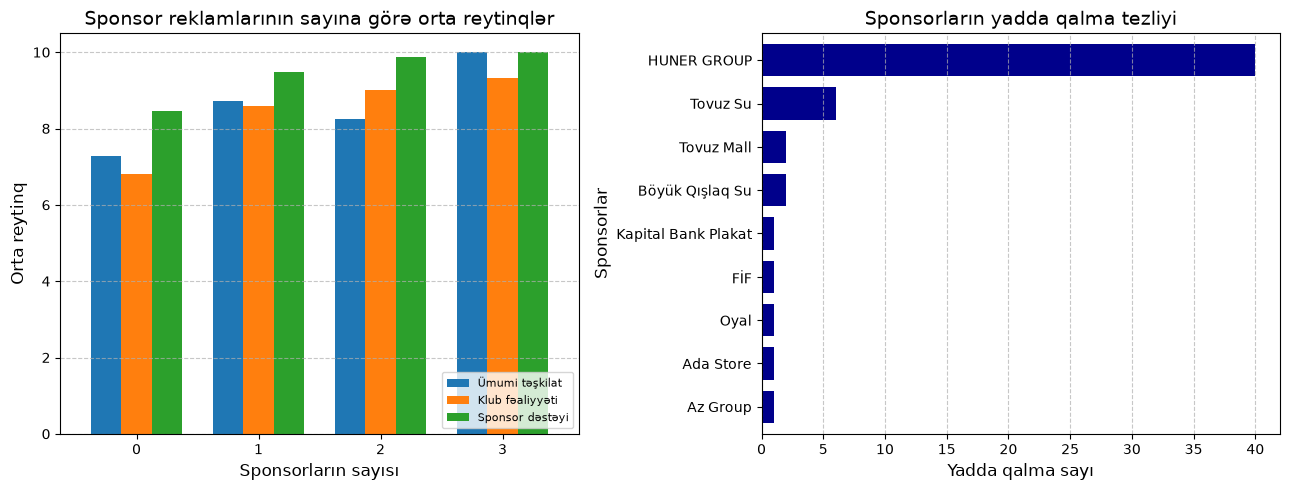

In [8]:
fig, axes = plt.subplots(1,2, figsize=(13,5))

#sol tərəf
summary[list(rating_cols.keys())].plot(kind='bar', ax=axes[0], rot=0, width=0.75)
axes[0].set_title('Sponsor reklamlarının sayına görə orta reytinqlər', fontsize=14)
axes[0].set_ylabel('Orta reytinq', fontsize=12)
axes[0].set_xlabel('Sponsorların sayısı', fontsize=12)
axes[0].set_ylim(0, 10.5)
axes[0].legend(loc='lower right', fontsize=8)
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

#sag tərəf
sponsor_freq.sort_values().plot(kind='barh', ax=axes[1], rot=0, width=0.75, color='darkblue')
axes[1].set_title('Sponsorların yadda qalma tezliyi', fontsize=14)
axes[1].set_xlabel('Yadda qalma sayı', fontsize=12)
axes[1].set_ylabel('Sponsorlar', fontsize=12)
axes[1].grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()

----------

## 2. Xərcləmə davranışı seqmentləri

Bu bölmədə respondentlərin stadion ərazisində qida/içki və klub fanşop məhsullarına 
nə qədər pul xərclədiyini araşdırırıq. Xərc sütunları yalnız "aldım" cavabı verənlər 
üçün doludur (digərlərində struktural NaN-dır), ona görə orta xərci hesablayarkən 
əvvəlcə yalnız real alıcıları filterləyirik. Sonra bu xərci cins, məşğuliyyət, yaş 
qrupu və uşaqla gəlmə vəziyyətinə görə qruplaşdırıb müqayisə edirik.

In [9]:
col_food_bought = 'Stadion ərazisində satışda olan qida və içkilər almısınızmı?'
col_food_spend  = 'Oyun zamanı satışda olan qida və içkilərə ortalama nə qədər pul xərcləmisiniz? məbləğ(AZN)'
col_fan_bought  = 'Stadion ərazisindəki fanşopdan klubun məhsullarını almısınızmı?'
col_fan_spend   = 'Oyun zamanı satışda olan klubun məhsullarına nə qədər pul xərcləmisiniz?'
col_with_children = 'Stadionda son izlədiyiniz oyunu sizinlə gələnlərin arasında uşaq var idi? bir neçə uşaq gəlmişdirsə, sayı "digər" bölməsində qeyd edə bilərsiniz'

In [10]:
col_gender = 'Cins'
col_age    = 'Yaşınız'
col_job    = 'Məşğuliyyət'
col_family = 'Ailə vəziyyəti'

In [11]:
print("=== Qida/İçki alıb-almama nisbəti ===")
df[col_food_bought].value_counts(normalize=True).round(2)

=== Qida/İçki alıb-almama nisbəti ===


Stadion ərazisində satışda olan qida və içkilər almısınızmı?
Bəli   0.56
Xeyr   0.44
Name: proportion, dtype: float64

In [12]:
print("=== Fanşop alıb-almama nisbəti ===")
print(df[col_fan_bought].value_counts(normalize=True).round(2))

=== Fanşop alıb-almama nisbəti ===
Stadion ərazisindəki fanşopdan klubun məhsullarını almısınızmı?
Xeyr   0.83
Bəli   0.17
Name: proportion, dtype: float64


In [13]:
buyers_food = df[df[col_food_bought] == 'Bəli']
buyers_fan  = df[df[col_fan_bought] == 'Bəli']
 
spend_by_gender = pd.DataFrame({
    'Qida/içki (AZN)': buyers_food.groupby(col_gender)[col_food_spend].mean().round(2),
    'Fanşop (AZN)':    buyers_fan.groupby(col_gender)[col_fan_spend].mean().round(2),
})
print("=== Cinsə görə orta xərc (yalnız alanlar) ===")
print(spend_by_gender)
print()

=== Cinsə görə orta xərc (yalnız alanlar) ===
       Qida/içki (AZN)  Fanşop (AZN)
Cins                                
Kişi              7.73         30.29
Qadın             4.00         10.00



In [14]:
spend_by_job = pd.DataFrame({
    'Qida/içki (AZN)': buyers_food.groupby(col_job)[col_food_spend].mean().round(2),
    'n_qida': buyers_food.groupby(col_job).size(),
    'Fanşop (AZN)':    buyers_fan.groupby(col_job)[col_fan_spend].mean().round(2),
    'n_fanşop': buyers_fan.groupby(col_job).size(),
})
print("=== Məşğuliyyətə görə orta xərc (yalnız alanlar) ===")
print(spend_by_job)
print()

=== Məşğuliyyətə görə orta xərc (yalnız alanlar) ===
                  Qida/içki (AZN)  n_qida  Fanşop (AZN)  n_fanşop
Məşğuliyyət                                                      
Avtomobil ustasi             5.50       1         30.00      1.00
Məktəbli                     6.00       1           NaN       NaN
Tələbə                       5.00       1           NaN       NaN
Təqaüdçü                     8.00       1           NaN       NaN
USTA                         2.00       1          2.00      1.00
İşləyirəm                    8.53      18         30.00      3.00
İşsizəm                      5.50       6         33.33      4.00



In [15]:
bins = [0, 20, 30, 40, 50, 100]
labels = ['<20', '20-29', '30-39', '40-49', '50+']
df['yas_qrupu'] = pd.cut(df[col_age], bins=bins, labels=labels, right=False)
buyers_food2 = df[df[col_food_bought] == 'Bəli']
spend_by_age = buyers_food2.groupby('yas_qrupu', observed=True)[col_food_spend].agg(['mean','count']).round(2)
print("=== Yaş qrupuna görə qida/içki xərci (yalnız alanlar) ===")
print(spend_by_age)


=== Yaş qrupuna görə qida/içki xərci (yalnız alanlar) ===
           mean  count
yas_qrupu             
<20        5.50      2
20-29     11.70      5
30-39      6.82     11
40-49      5.94      9
50+        7.50      2


In [16]:
buyers_food3 = df[df[col_food_bought] == 'Bəli']
spend_by_children = buyers_food3.groupby(col_with_children)[col_food_spend].agg(['mean','count']).round(2)
print("=== Uşaqla gəlmə vəziyyətinə görə qida/içki xərci ===")
print(spend_by_children)

=== Uşaqla gəlmə vəziyyətinə görə qida/içki xərci ===
                                                    mean  count
Stadionda son izlədiyiniz oyunu sizinlə gələnlə...             
Bəli                                                7.00     16
Xeyr                                                7.77     13


In [17]:
df['Stadionda son izlədiyiniz oyunu sizinlə gələnlərin arasında uşaq var idi? bir neçə uşaq gəlmişdirsə, sayı "digər" bölməsində qeyd edə bilərsiniz'].value_counts()

Stadionda son izlədiyiniz oyunu sizinlə gələnlərin arasında uşaq var idi? bir neçə uşaq gəlmişdirsə, sayı "digər" bölməsində qeyd edə bilərsiniz
Bəli    29
Xeyr    23
Name: count, dtype: int64

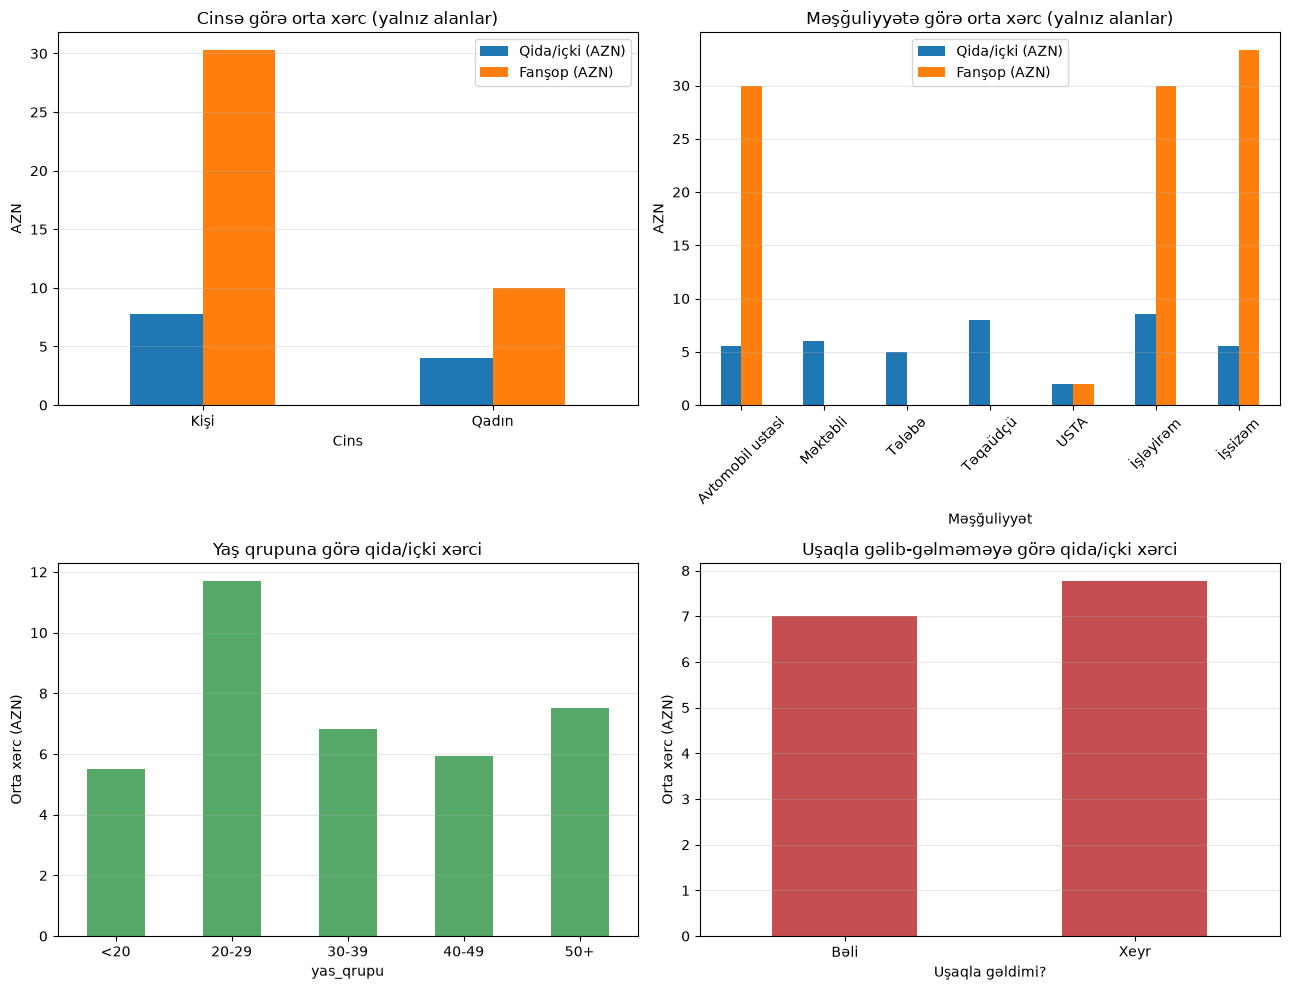

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
 
spend_by_gender.plot(kind='bar', ax=axes[0,0], rot=0)
axes[0,0].set_title('Cinsə görə orta xərc (yalnız alanlar)')
axes[0,0].set_ylabel('AZN')
axes[0,0].grid(axis='y', alpha=0.3)
 
spend_by_job[['Qida/içki (AZN)','Fanşop (AZN)']].plot(kind='bar', ax=axes[0,1], rot=45)
axes[0,1].set_title('Məşğuliyyətə görə orta xərc (yalnız alanlar)')
axes[0,1].set_ylabel('AZN')
axes[0,1].grid(axis='y', alpha=0.3)
 
spend_by_age['mean'].plot(kind='bar', ax=axes[1,0], rot=0, color='#55A868')
axes[1,0].set_title('Yaş qrupuna görə qida/içki xərci')
axes[1,0].set_ylabel('Orta xərc (AZN)')
axes[1,0].grid(axis='y', alpha=0.3)
 
spend_by_children['mean'].plot(kind='bar', ax=axes[1,1], rot=0, color='#C44E52')
axes[1,1].set_title('Uşaqla gəlib-gəlməməyə görə qida/içki xərci')
axes[1,1].set_xlabel('Uşaqla gəldimi?')
axes[1,1].set_ylabel('Orta xərc (AZN)')
axes[1,1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()

---------

## 3. Loyallıq və tövsiyə əlaqəsi

Burada respondentlərin "növbəti oyunları izləmək istəyi" və "dostlara tövsiyə etmə" 
cavablarını digər reytinq sütunları ilə əlaqələndiririk ki, geri qayıtmama qərarına 
ən çox təsir edən amilləri (ab-hava, təmizlik, təşkilat və s.) müəyyənləşdirək. 
Həmçinin "Xeyr" deyən respondentlərin bildirdiyi konkret problemləri və rayon/kəndə 
görə loyallıq nisbətini nəzərdən keçiririk.

**Qeyd:** Bu bölmədəki problem-tezliyi kodu sadə `split(', ')` üsulundan istifadə edir 
— bu, yalnız aşağıdakı 6 nəfərlik ("Xeyr" deyən) alt-qrup üçün etibarlıdır, çünki 
həmin qrupun bütün cavabları vergüllə ayrılıb. Bütün 52 respondent üzərində daha 
etibarlı təhlil üçün aşağıdakı whitelist/regex üsuluna bax.

In [35]:
col_return    = 'Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?'
col_recommend = 'Son oyundakı təcrübənizə əsasən, dostlarınıza Turan Tovuz PFK-nın oyunlarını stadionda izləməyi tövsiyə edərsiniz?'
col_region    = 'Harada yaşayırsınız, oyunu izləməyə haradan gəlmisiniz? rayon/kəndin adını qeyd edin'
problem_cols  = [
    'Xahiş edirik stadiona gedərkən üzləşdiyiniz problemləri qeyd edin:',
    'Xahiş edirik stadionda üzləşdiyiniz problemləri qeyd edin:',
    'Xahiş edirik stadiondan çıxarkən üzləşdiyiniz problemləri qeyd edin:',
]
rating_cols = [
    'Bilet alma prosesini necə qiymətləndirirsiniz?',
    'Bilet yoxlayan əməkdaşların işini necə qiymətləndirirsiniz?',
    'Təhlükəsizlik xidmətinin işini necə qiymətləndirirsiniz?',
    'Könüllülərin işini necə qiymətləndirirsiniz? (istiqamətin göstərilməsi, sualların cavablandırılması və s.)',
    'Tribunaların təmizliyini necə qiymətləndirirsiniz?',
    'Tualetlərin təmizliyini necə qiymətləndirirsiniz?',
    'Stadionda olan ab-havanı necə qiymətləndirirsiniz?',
    'Ümumi oyunun təşkilini necə qiymətləndirirsiniz?',
]

In [36]:
# 1) Geri qayitmaq isteyi vs reytinqlər
ret_summary = df.groupby(col_return)[rating_cols].mean().round(2).T
ret_summary['fərq'] = (ret_summary['Bəli'] - ret_summary['Xeyr']).round(2)
print("=== Növbəti oyunları izləmək istəyib-istəməməyə görə orta reytinqlər ===")
print(ret_summary.sort_values('fərq'))

=== Növbəti oyunları izləmək istəyib-istəməməyə görə orta reytinqlər ===
Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?  Bəli  \
Könüllülərin işini necə qiymətləndirirsiniz? (i...                                                       8.61   
Təhlükəsizlik xidmətinin işini necə qiymətləndi...                                                       9.11   
Bilet alma prosesini necə qiymətləndirirsiniz?                                                           9.04   
Bilet yoxlayan əməkdaşların işini necə qiymətlə...                                                       8.76   
Tribunaların təmizliyini necə qiymətləndirirsiniz?                                                       8.61   
Tualetlərin təmizliyini necə qiymətləndirirsiniz?                                                        8.13   
Ümumi oyunun təşkilini necə qiymətləndirirsiniz?                                                         8.63   
Stadionda olan ab-havan

In [21]:
# ---- 2) Tövsiyə vs reytinqlər ----
rec_summary = df.groupby(col_recommend)[rating_cols].mean().round(2).T
print("=== Tövsiyə niyyətinə görə orta reytinqlər (Bəli vs Xeyr) ===")
print(rec_summary)
print()

=== Tövsiyə niyyətinə görə orta reytinqlər (Bəli vs Xeyr) ===
Son oyundakı təcrübənizə əsasən, dostlarınıza Turan Tovuz PFK-nın oyunlarını stadionda izləməyi tövsiyə edərsiniz?  Bəli  \
Bilet alma prosesini necə qiymətləndirirsiniz?                                                                      9.11   
Bilet yoxlayan əməkdaşların işini necə qiymətlə...                                                                  8.72   
Təhlükəsizlik xidmətinin işini necə qiymətləndi...                                                                  9.09   
Könüllülərin işini necə qiymətləndirirsiniz? (i...                                                                  8.64   
Tribunaların təmizliyini necə qiymətləndirirsiniz?                                                                  8.64   
Tualetlərin təmizliyini necə qiymətləndirirsiniz?                                                                   8.09   
Stadionda olan ab-havanı necə qiymətləndirirsiniz?                    

In [22]:
#geri gelmek istemeyenlerin bildirdiyi problemlər
neg_respondents = df[df[col_return] == 'Xeyr']
all_problems = pd.concat([neg_respondents[c] for c in problem_cols]).dropna()
exploded_problems = all_problems.str.split(', ').explode()
exploded_problems = exploded_problems[exploded_problems != 'Heç bir problemlə üzləşmədim']
problem_freq = exploded_problems.value_counts()
print("=== 'Geri qayıtmaq istəmirəm' deyənlərin bildirdiyi problemlər ===")
print(problem_freq)
print()

=== 'Geri qayıtmaq istəmirəm' deyənlərin bildirdiyi problemlər ===
Stadiondan çıxış zamanı sıxlıq olması           2
Stadionun parkinqində yerin az olması           1
Stadiona giriş də bilet yoxlayanın az olması    1
Oturacağım çirkli olması                        1
Tualetlərin çirkli olması                       1
Avtomobil tıxacları                             1
Name: count, dtype: int64



In [23]:
region_counts = df[col_region].value_counts()
valid_regions = region_counts[region_counts >= 2].index
region_loyalty = (
    df[df[col_region].isin(valid_regions)]
    .groupby(col_region)[col_return]
    .apply(lambda s: (s == 'Bəli').mean())
    .round(2)
    .sort_values()
)
print("=== Rayon/kəndə görə geri qayıtma nisbəti (n>=2) ===")
print(region_loyalty)

=== Rayon/kəndə görə geri qayıtma nisbəti (n>=2) ===
Harada yaşayırsınız, oyunu izləməyə haradan gəlmisiniz? rayon/kəndin adını qeyd edin
Əsrik Cırdaxan kəndi   0.00
Aşağı Quşçu kəndi      0.67
Tovuz şəhəri           0.88
Qeyd olunmayıb         0.93
Düz Cırdaxan kəndi     1.00
Bozalqanlı kəndi       1.00
Qovlar kəndi           1.00
Name: Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?, dtype: float64


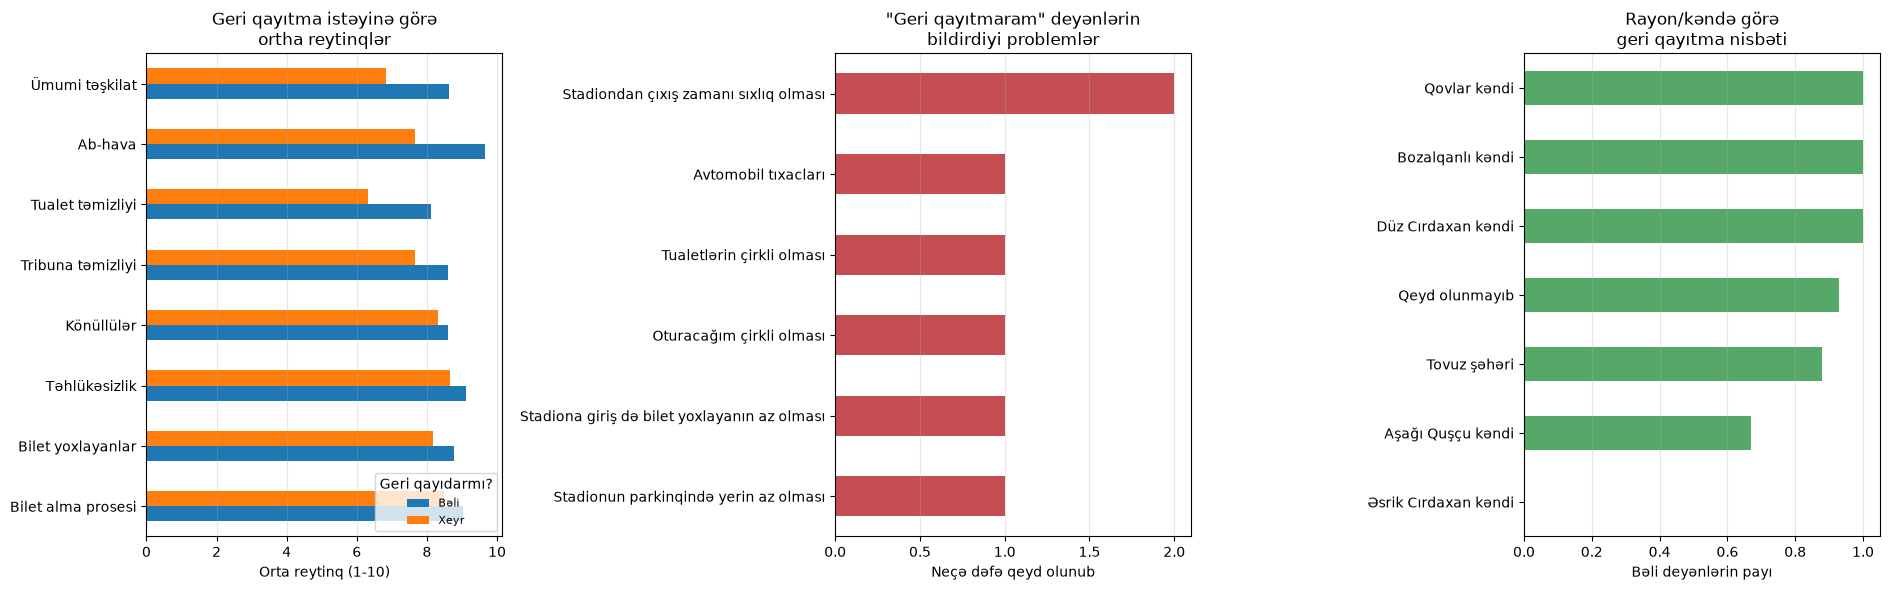

In [24]:
fig, axes = plt.subplots(1, 3, figsize=(19, 6))
 
# Sol panel üçün qısa etiketlər (uzun sütun adları grafiki oxunmaz edir)
short_labels = {
    'Bilet alma prosesini necə qiymətləndirirsiniz?': 'Bilet alma prosesi',
    'Bilet yoxlayan əməkdaşların işini necə qiymətləndirirsiniz?': 'Bilet yoxlayanlar',
    'Təhlükəsizlik xidmətinin işini necə qiymətləndirirsiniz?': 'Təhlükəsizlik',
    'Könüllülərin işini necə qiymətləndirirsiniz? (istiqamətin göstərilməsi, sualların cavablandırılması və s.)': 'Könüllülər',
    'Tribunaların təmizliyini necə qiymətləndirirsiniz?': 'Tribuna təmizliyi',
    'Tualetlərin təmizliyini necə qiymətləndirirsiniz?': 'Tualet təmizliyi',
    'Stadionda olan ab-havanı necə qiymətləndirirsiniz?': 'Ab-hava',
    'Ümumi oyunun təşkilini necə qiymətləndirirsiniz?': 'Ümumi təşkilat',
}
ret_plot = ret_summary[['Bəli','Xeyr']].rename(index=short_labels)
ret_plot.plot(kind='barh', ax=axes[0])
axes[0].set_title('Geri qayıtma istəyinə görə\northa reytinqlər')
axes[0].set_xlabel('Orta reytinq (1-10)')
axes[0].legend(title='Geri qayıdarmı?', fontsize=8, loc='lower right')
axes[0].grid(axis='x', alpha=0.3)
 
problem_freq.sort_values().plot(kind='barh', ax=axes[1], color='#C44E52')
axes[1].set_title('"Geri qayıtmaram" deyənlərin\nbildirdiyi problemlər')
axes[1].set_xlabel('Neçə dəfə qeyd olunub')
axes[1].grid(axis='x', alpha=0.3)
 
region_loyalty.rename('').plot(kind='barh', ax=axes[2], color='#55A868')
axes[2].set_title('Rayon/kəndə görə\ngeri qayıtma nisbəti')
axes[2].set_xlabel('Bəli deyənlərin payı')
axes[2].set_ylabel('')
axes[2].set_xlim(0, 1.05)
axes[2].grid(axis='x', alpha=0.3)
 
plt.tight_layout()

------


## 4. Ümumi problem tezliyi (whitelist/regex üsulu)

Stadiona gedərkən/stadionda/çıxarkən problem sütunları təmiz multi-select deyil — 
sərbəst mətnlə qarışıqdır: bəzi cavablar iki problemi vergül əvəzinə **nöqtə** ilə 
ayırır, bəziləri isə vergülü tag-ayırıcı yox, **təbii cümlə durğusu** kimi işlədir 
(məs. "yolun uzun olması" tək bir fikirdir, iki yox). Sadə `split(', ')` bu halları 
səhv parçalayacağı üçün, sponsor/rayon təmizləməsində istifadə etdiyimiz eyni 
prinsiplə hər problem üçün ayrıca **regex imza** təyin edirik və mətndə bu imzaları 
müstəqil axtarırıq (bölmədən deyil, axtarışdan istifadə edərək). Bu, bütün 52 
respondent üzrə etibarlı ümumi problem tezliyini verir və whitelist-ə uyğun 
gəlməyən mətnləri ayrıca xəbərdarlıq kimi göstərir ki, heç nə səssizcə itməsin.

In [25]:
PROBLEM_PATTERNS: list[tuple[str, str]] = [
    (r'(?i)tribunanın\s*üstü.*bağlı', 'Tribunanın üstünün bağlı olması'),
    (r'(?i)parkinq.*az', 'Parkinq yerinin az olması'),
    (r'(?i)çatmaq\s*üçün\s*sərf\s*olunan\s*vaxt', 'Stadiona gediş yolunun/vaxtının uzun olması'),
    (r'(?i)sıraların\s*çox\s*olması|giriş\s*zamanı\s*sıra', 'Girişdə sıra/növbənin çox olması'),
    (r'(?i)butulka.*qapa[ğg]', 'Butulka qapağının açıq olması (giriş qaydası)'),
    (r'(?i)tütün|siqaret', 'Tütün məhsullarının istifadəsi'),
    (r'(?i)smiçka|çırtdam', 'Partladıcı səs-küy (petard/smiçka)'),
    (r'(?i)qadın\s*tualet', 'Qadın tualetindən kişilərin istifadəsi'),
    (r'(?i)oturaca[ğg]ım\s*çirkli|oturacaqlarda.*çux', 'Oturacaqların çirkli olması'),
    (r'(?i)tualetlərin\s*çirkli', 'Tualetlərin çirkli olması'),
    (r'(?i)suların\s*qapa[ğg]ını\s*aç', 'Su şüşələrinin qapağının açıq satılması'),
    (r'(?i)biletimdə\s*göstərilən\s*yerdə\s*başqası', 'Biletdəki yerdə başqasının oturması'),
    (r'(?i)giriş\s*də\s*bilet\s*yoxlayanın\s*az', 'Bilet yoxlayan işçilərin az olması'),
    (r'(?i)çıxış\s*zamanı\s*sıxlıq', 'Çıxışda sıxlıq olması'),
    (r'(?i)birinci\s*time\s*çıxanda\s*qap[ıi]n[ıi]n\s*bağlı', 'Fasilədə çıxış qapısının bağlı olması'),
    (r'(?i)avtomobil\s*tıxac', 'Avtomobil tıxacları'),
    (r'(?i)maşın\s*saxlamaq\s*olmur|polislər\s*qoymur|çərimə\s*yazır', 'Parklanma qadağası / cərimə'),
    (r'(?i)söyüş', 'Söyüş söyülməsi'),
]
_COMPILED = [(re.compile(p), lbl) for p, lbl in PROBLEM_PATTERNS]
_NO_PROBLEM_RE = re.compile(r'(?i)heç\s*bir\s*problem')
 
 
def extract_problems(text: str) -> list[str]:
    """Mətndəki bütün tanınan problem etiketlərini (whitelist) tapır."""
    if pd.isna(text) or _NO_PROBLEM_RE.search(str(text)):
        return []
    found = [lbl for pattern, lbl in _COMPILED if pattern.search(str(text))]
    return found
 
 
# ---- Bütün 52 respondent üzrə, 3 sütun üzrə tətbiq ----
all_labels = []
unmatched_texts = []
for col in problem_cols:
    for val in df[col].dropna():
        labels = extract_problems(val)
        all_labels.extend(labels)
        if not labels and not _NO_PROBLEM_RE.search(str(val)):
            unmatched_texts.append((col, val))
 
problem_freq = pd.Series(all_labels).value_counts()
print("=== ÜMUMİ (52 respondent) problem tezliyi — whitelist/regex üsulu ===")
print(problem_freq)
print()
 
if unmatched_texts:
    print("Diqqət: heç bir whitelist etiketinə uyğun gəlməyən mətnlər (əl ilə yoxla):")
    for col, val in unmatched_texts:
        print(f"  [{col[:30]}...] {val!r}")
else:
    print("Bütün cavablar uğurla təsnif olundu, uyğunlaşdırılmayan mətn qalmadı.")
print()

=== ÜMUMİ (52 respondent) problem tezliyi — whitelist/regex üsulu ===
Oturacaqların çirkli olması                      8
Çıxışda sıxlıq olması                            6
Parkinq yerinin az olması                        5
Söyüş söyülməsi                                  4
Avtomobil tıxacları                              4
Tütün məhsullarının istifadəsi                   3
Tualetlərin çirkli olması                        3
Stadiona gediş yolunun/vaxtının uzun olması      2
Girişdə sıra/növbənin çox olması                 2
Biletdəki yerdə başqasının oturması              2
Tribunanın üstünün bağlı olması                  1
Butulka qapağının açıq olması (giriş qaydası)    1
Partladıcı səs-küy (petard/smiçka)               1
Qadın tualetindən kişilərin istifadəsi           1
Su şüşələrinin qapağının açıq satılması          1
Bilet yoxlayan işçilərin az olması               1
Fasilədə çıxış qapısının bağlı olması            1
Parklanma qadağası / cərimə                      1
Name: count,

-------

## 5. Coğrafi və demoqrafik profil

Bu bölmədə "kim iştirak edir" sualına cavab veririk: rayon/kənd, yaş, cins 
paylanması və stadiona necə gəldikləri (nəqliyyat vasitəsi). Rayon/kənd adlarını 
"Tovuz şəhəri / Kənd / Digər / Qeyd olunmayıb" kimi 4 əsas qrupa toplayırıq ki, 
14 fərqli kənd adı əvəzinə mənalı, oxunaqlı bir müqayisə əldə edək. Sonda nəqliyyat 
seçiminin coğrafi məsafə ilə məntiqli əlaqələndiyini yoxlayırıq (sanity check).

In [26]:
col_region    = 'Harada yaşayırsınız, oyunu izləməyə haradan gəlmisiniz? rayon/kəndin adını qeyd edin'
col_transport = 'Stadiona getmək üçün hansı vasitədən istifadə etmisiniz?'
col_gender    = 'Cins'
col_age       = 'Yaşınız'

In [27]:
region_counts = df[col_region].value_counts()
print("=== Rayon/kənd üzrə say ===")
print(region_counts)
print()

=== Rayon/kənd üzrə say ===
Harada yaşayırsınız, oyunu izləməyə haradan gəlmisiniz? rayon/kəndin adını qeyd edin
Tovuz şəhəri            17
Qeyd olunmayıb          15
Aşağı Quşçu kəndi        3
Bozalqanlı kəndi         3
Düz Cırdaxan kəndi       2
Qovlar kəndi             2
Əsrik Cırdaxan kəndi     2
Azaflı kəndi             1
Əlimərdanlı kəndi        1
Cəlilli kəndi            1
Köhnəqala kəndi          1
Alakol kəndi             1
Bakı şəhəri              1
Əyyublu kəndi            1
Xatınlı kəndi            1
Name: count, dtype: int64



In [28]:
def bucket_region(v):
    if v == 'Tovuz şəhəri':
        return 'Tovuz şəhəri'
    if v == 'Qeyd olunmayıb':
        return 'Qeyd olunmayıb'
    if pd.isna(v):
        return 'Qeyd olunmayıb'
    return 'Kənd (Tovuz rayonu)' if 'kəndi' in str(v) else 'Digər (Bakı və s.)'
 
df['region_bucket'] = df[col_region].apply(bucket_region)
bucket_counts = df['region_bucket'].value_counts()
print("=== Şəhər/Kənd/Digər bölgüsü ===")
print(bucket_counts)
print()

=== Şəhər/Kənd/Digər bölgüsü ===
region_bucket
Kənd (Tovuz rayonu)    19
Tovuz şəhəri           17
Qeyd olunmayıb         15
Digər (Bakı və s.)      1
Name: count, dtype: int64



In [29]:
print("=== Cins bölgüsü ===")
print(df[col_gender].value_counts())
print()
print("=== Yaş statistikası ===")
print(df[col_age].describe().round(1))
print()

=== Cins bölgüsü ===
Cins
Kişi     49
Qadın     3
Name: count, dtype: int64

=== Yaş statistikası ===
count   52.00
mean    37.00
std     10.50
min     16.00
25%     30.00
50%     36.50
75%     42.20
max     71.00
Name: Yaşınız, dtype: float64



In [30]:
transport_by_bucket = pd.crosstab(
    df['region_bucket'], 
    df[col_transport], 
    colnames=['Nəqliyyat'], # Başlığı "Nəqliyyat" kimi qısaldır
    normalize='index'
).round(2)

print("=== Rayon tipinə görə nəqliyyat seçimi (sətir %) ===")
print(transport_by_bucket)

=== Rayon tipinə görə nəqliyyat seçimi (sətir %) ===
Nəqliyyat            Piyada  Taksi  İctimai nəqliyyat  Şəxsi avtomobil
region_bucket                                                         
Digər (Bakı və s.)     0.00   0.00               0.00             1.00
Kənd (Tovuz rayonu)    0.00   0.21               0.21             0.58
Qeyd olunmayıb         0.13   0.20               0.13             0.53
Tovuz şəhəri           0.59   0.00               0.06             0.35


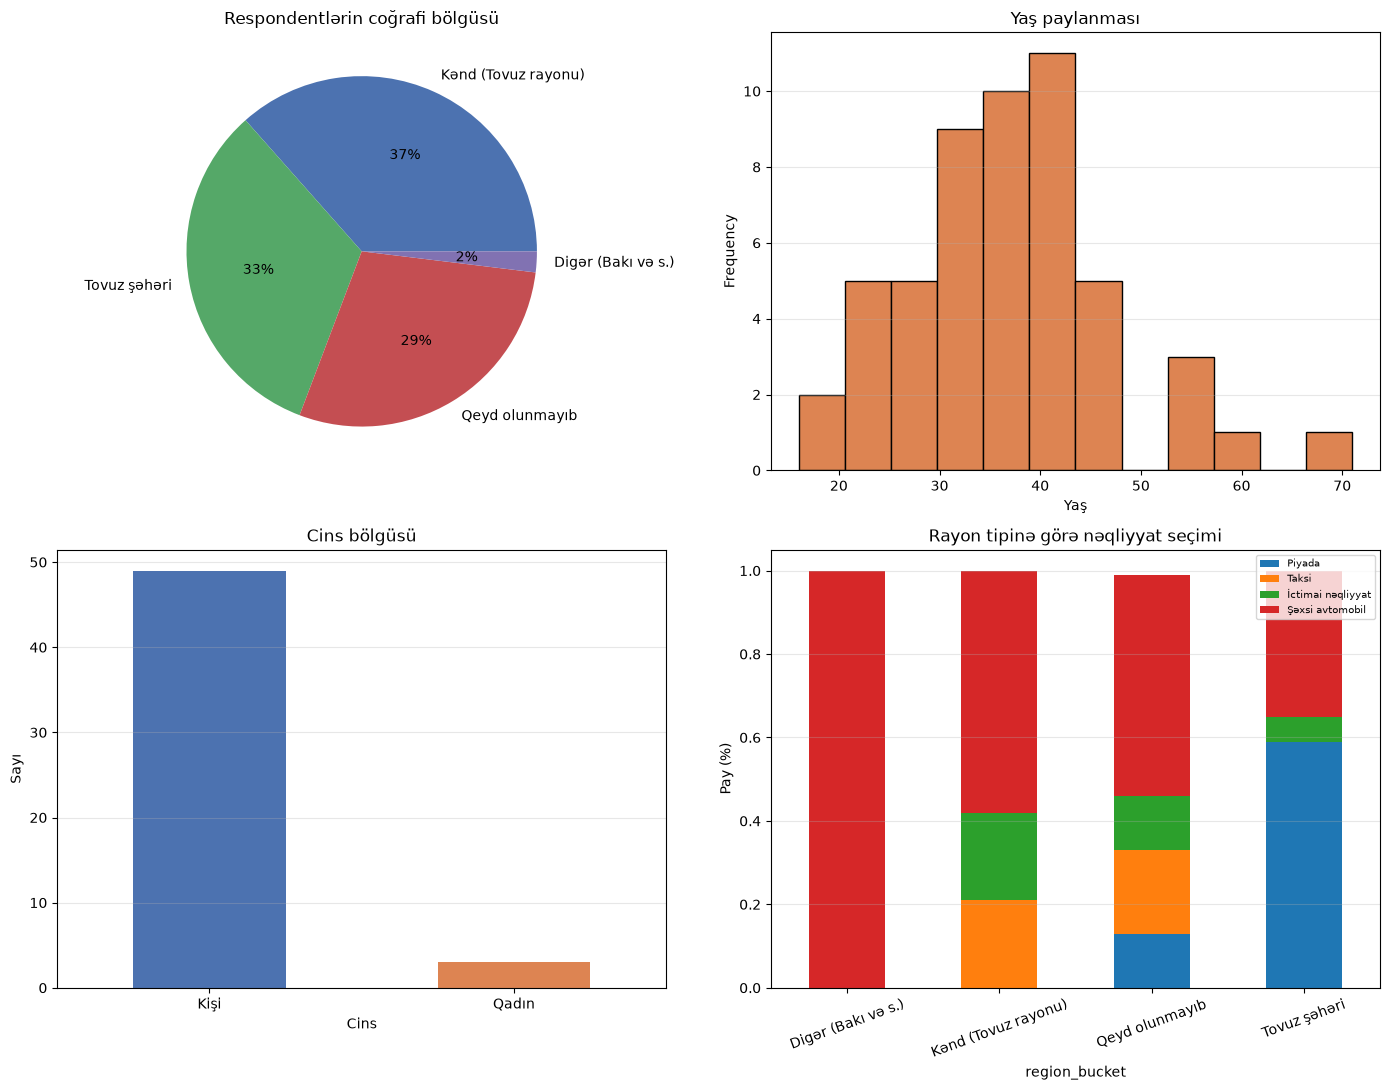

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
 
bucket_counts.plot(kind='pie', ax=axes[0,0], autopct='%1.0f%%', ylabel='',
                    colors=['#4C72B0','#55A868','#C44E52','#8172B2'])
axes[0,0].set_title('Respondentlərin coğrafi bölgüsü')
 
df[col_age].plot(kind='hist', bins=12, ax=axes[0,1], color='#DD8452', edgecolor='black')
axes[0,1].set_title('Yaş paylanması')
axes[0,1].set_xlabel('Yaş')
axes[0,1].grid(axis='y', alpha=0.3)
 
df[col_gender].value_counts().plot(kind='bar', ax=axes[1,0], color=['#4C72B0','#DD8452'], rot=0)
axes[1,0].set_title('Cins bölgüsü')
axes[1,0].set_ylabel('Sayı')
axes[1,0].grid(axis='y', alpha=0.3)
 
transport_by_bucket.plot(kind='bar', ax=axes[1,1], stacked=True, rot=20)
axes[1,1].set_title('Rayon tipinə görə nəqliyyat seçimi')
axes[1,1].set_ylabel('Pay (%)')
axes[1,1].legend(fontsize=7, loc='upper right')
axes[1,1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()

--------

## 6. Reytinq sütunları arasında korrelyasiya matrisi

10 reytinq sütununun (bilet, təhlükəsizlik, təmizlik, ab-hava və s.) bir-biri ilə 
nə dərəcədə əlaqəli olduğunu Pearson korrelyasiyası ilə ölçürük. Bu, həm sorğu 
dizaynının keyfiyyətini yoxlamağa kömək edir (təkrarlanan suallar varmı), həm də 
hansı təcrübə sahələrinin "birgə hərəkət etdiyini" (məs. təmizlik göstəriciləri) 
üzə çıxarır. Nəticə heatmap şəklində vizuallaşdırılır.

In [37]:
rating_cols = [
    'Bilet alma prosesini necə qiymətləndirirsiniz?',
    'Bilet yoxlayan əməkdaşların işini necə qiymətləndirirsiniz?',
    'Təhlükəsizlik xidmətinin işini necə qiymətləndirirsiniz?',
    'Könüllülərin işini necə qiymətləndirirsiniz? (istiqamətin göstərilməsi, sualların cavablandırılması və s.)',
    'Tribunaların təmizliyini necə qiymətləndirirsiniz?',
    'Tualetlərin təmizliyini necə qiymətləndirirsiniz?',
    'Stadionda olan ab-havanı necə qiymətləndirirsiniz?',
    'Ümumi oyunun təşkilini necə qiymətləndirirsiniz?',
    'Klubun faəliyyətini necə dəyərləndirirsiniz?',
    'Sponsorun dəstəyini necə dəyərləndirirsiniz?',
]
 
# Qısa etiketlər - heatmap-də uzun sual mətnləri oxunmaz olardı
short_labels = {
    'Bilet alma prosesini necə qiymətləndirirsiniz?': 'Bilet alma',
    'Bilet yoxlayan əməkdaşların işini necə qiymətləndirirsiniz?': 'Bilet yoxlayanlar',
    'Təhlükəsizlik xidmətinin işini necə qiymətləndirirsiniz?': 'Təhlükəsizlik',
    'Könüllülərin işini necə qiymətləndirirsiniz? (istiqamətin göstərilməsi, sualların cavablandırılması və s.)': 'Könüllülər',
    'Tribunaların təmizliyini necə qiymətləndirirsiniz?': 'Tribuna təmizliyi',
    'Tualetlərin təmizliyini necə qiymətləndirirsiniz?': 'Tualet təmizliyi',
    'Stadionda olan ab-havanı necə qiymətləndirirsiniz?': 'Ab-hava',
    'Ümumi oyunun təşkilini necə qiymətləndirirsiniz?': 'Ümumi təşkilat',
    'Klubun faəliyyətini necə dəyərləndirirsiniz?': 'Klub fəaliyyəti',
    'Sponsorun dəstəyini necə dəyərləndirirsiniz?': 'Sponsor dəstəyi',
}

In [41]:
corr_df = df[rating_cols].rename(columns=short_labels)
corr = corr_df.corr()

In [ ]:
pairs = (
    corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
    .stack()
    .rename('korrelyasiya')
    .sort_values(ascending=False)
)

=== Ən güclü müsbət əlaqəli 8 cüt ===
Tribuna təmizliyi  Tualet təmizliyi   0.57
Ab-hava            Ümumi təşkilat     0.57
Bilet yoxlayanlar  Təhlükəsizlik      0.51
Klub fəaliyyəti    Sponsor dəstəyi    0.50
Ab-hava            Klub fəaliyyəti    0.46
Ümumi təşkilat     Klub fəaliyyəti    0.45
Tribuna təmizliyi  Ümumi təşkilat     0.41
Təhlükəsizlik      Könüllülər         0.40
Name: korrelyasiya, dtype: float64


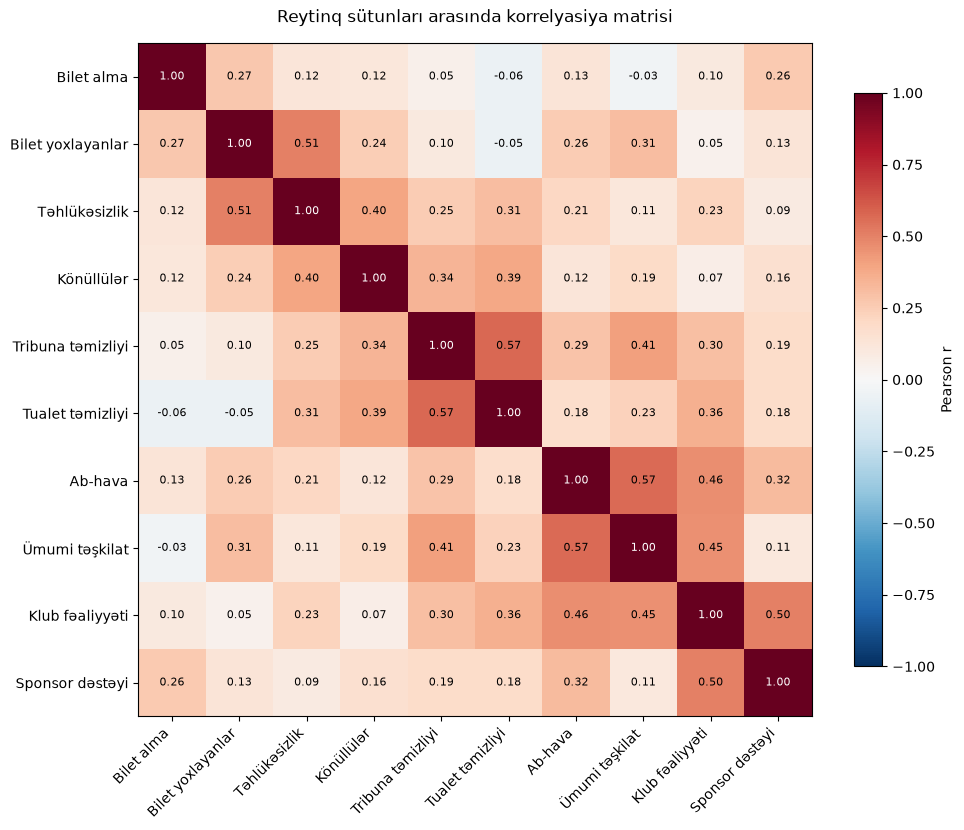

In [40]:
fig, ax = plt.subplots(figsize=(10, 8.5))
im = ax.imshow(corr, cmap='RdBu_r', vmin=-1, vmax=1)
 
ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))
ax.set_xticklabels(corr.columns, rotation=45, ha='right')
ax.set_yticklabels(corr.columns)
 
# Hər xanaya ədədi dəyəri yazırıq
for i in range(len(corr)):
    for j in range(len(corr)):
        val = corr.iloc[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', color=color, fontsize=8)
 
ax.set_title('Reytinq sütunları arasında korrelyasiya matrisi', pad=15)
fig.colorbar(im, ax=ax, shrink=0.8, label='Pearson r')
plt.tight_layout()

----------

## 7. Məlumat mənbəyi və bilet kanalı analizi

Respondentlərin oyunu necə tez-tez izlədiyini, oyun barədə məlumatı haradan 
aldığını və bileti hansı kanaldan əldə etdiyini araşdırırıq. "Bileti haradan 
almısınız?" sütunu sərbəst mətn ehtiva etdiyi üçün (məs. "Biletlər 
Kamran") whitelist/regex yanaşması ilə 6 aydın kateqoriyaya salırıq. Sonda 
məlumat mənbəyinə görə geri qayıtma nisbətini müqayisə edərək, hansı kanalın 
daha loyal tamaşaçı gətirdiyini görürük.

In [42]:
col_frequency = 'Turan Tovuz PFK-nın oyunlarını hansı tezlikdə izləyirsiniz?'
col_info      = 'Oyun barədə məlumatı haradan əldə etmisiniz?'
col_ticket    = 'Bileti haradan almısınız?'
col_return    = 'Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?'

In [43]:
TICKET_PATTERNS: list[tuple[str, str]] = [
    (r'(?i)kassa', 'Stadionun kassası'),
    (r'(?i)giriş', 'Stadionun girişi'),
    (r'(?i)səyyar', 'Səyyar satış məntəqəsi'),
    (r'(?i)mərkəz', 'Şəhər mərkəzi satış məntəqəsi'),
    (r'(?i)dəvətnamə|kamran|alınmır', 'Dəvətnamə / şəxs vasitəsilə (pulsuz)'),
]
_COMPILED_TICKET = [(re.compile(p), lbl) for p, lbl in TICKET_PATTERNS]

In [46]:
def canon_ticket(v):
    if pd.isna(v):
        return 'Qeyd olunmayıb'
    for pattern, label in _COMPILED_TICKET:
        if pattern.search(str(v)):
            return label
    return 'Qazi' 

In [47]:
df['ticket_channel'] = df[col_ticket].apply(canon_ticket)
 
print("=== İzləmə tezliyi ===")
print(df[col_frequency].value_counts())
print()
print("=== Məlumat mənbəyi ===")
print(df[col_info].value_counts())
print()
print("=== Bilet kanalı (kanonikləşdirilmiş) ===")
print(df['ticket_channel'].value_counts())
print()

=== İzləmə tezliyi ===
Turan Tovuz PFK-nın oyunlarını hansı tezlikdə izləyirsiniz?
Hər oyununu izləyirəm       46
Nadir izləyirəm              5
Əksər oyunları izləyirəm     1
Name: count, dtype: int64

=== Məlumat mənbəyi ===
Oyun barədə məlumatı haradan əldə etmisiniz?
Sosial media kanallarından       34
Tanışlardan                      14
Şəhərdə yerləşən posterlərdən     3
Livescore proqram                 1
Name: count, dtype: int64

=== Bilet kanalı (kanonikləşdirilmiş) ===
ticket_channel
Stadionun kassası                       38
Dəvətnamə / şəxs vasitəsilə (pulsuz)     6
Stadionun girişi                         4
Səyyar satış məntəqəsi                   2
Qazi                                     1
Şəhər mərkəzi satış məntəqəsi            1
Name: count, dtype: int64



In [48]:
info_loyalty = (
    df.groupby(col_info)[col_return]
    .apply(lambda s: (s == 'Bəli').mean())
    .round(2)
)
info_n = df.groupby(col_info).size()
info_summary = pd.DataFrame({'geri_qayıtma_nisbəti': info_loyalty, 'n': info_n})
print("=== Məlumat mənbəyinə görə geri qayıtma nisbəti ===")
print(info_summary.sort_values('geri_qayıtma_nisbəti'))

=== Məlumat mənbəyinə görə geri qayıtma nisbəti ===
                                              geri_qayıtma_nisbəti   n
Oyun barədə məlumatı haradan əldə etmisiniz?                          
Livescore proqram                                             0.00   1
Tanışlardan                                                   0.86  14
Sosial media kanallarından                                    0.91  34
Şəhərdə yerləşən posterlərdən                                 1.00   3


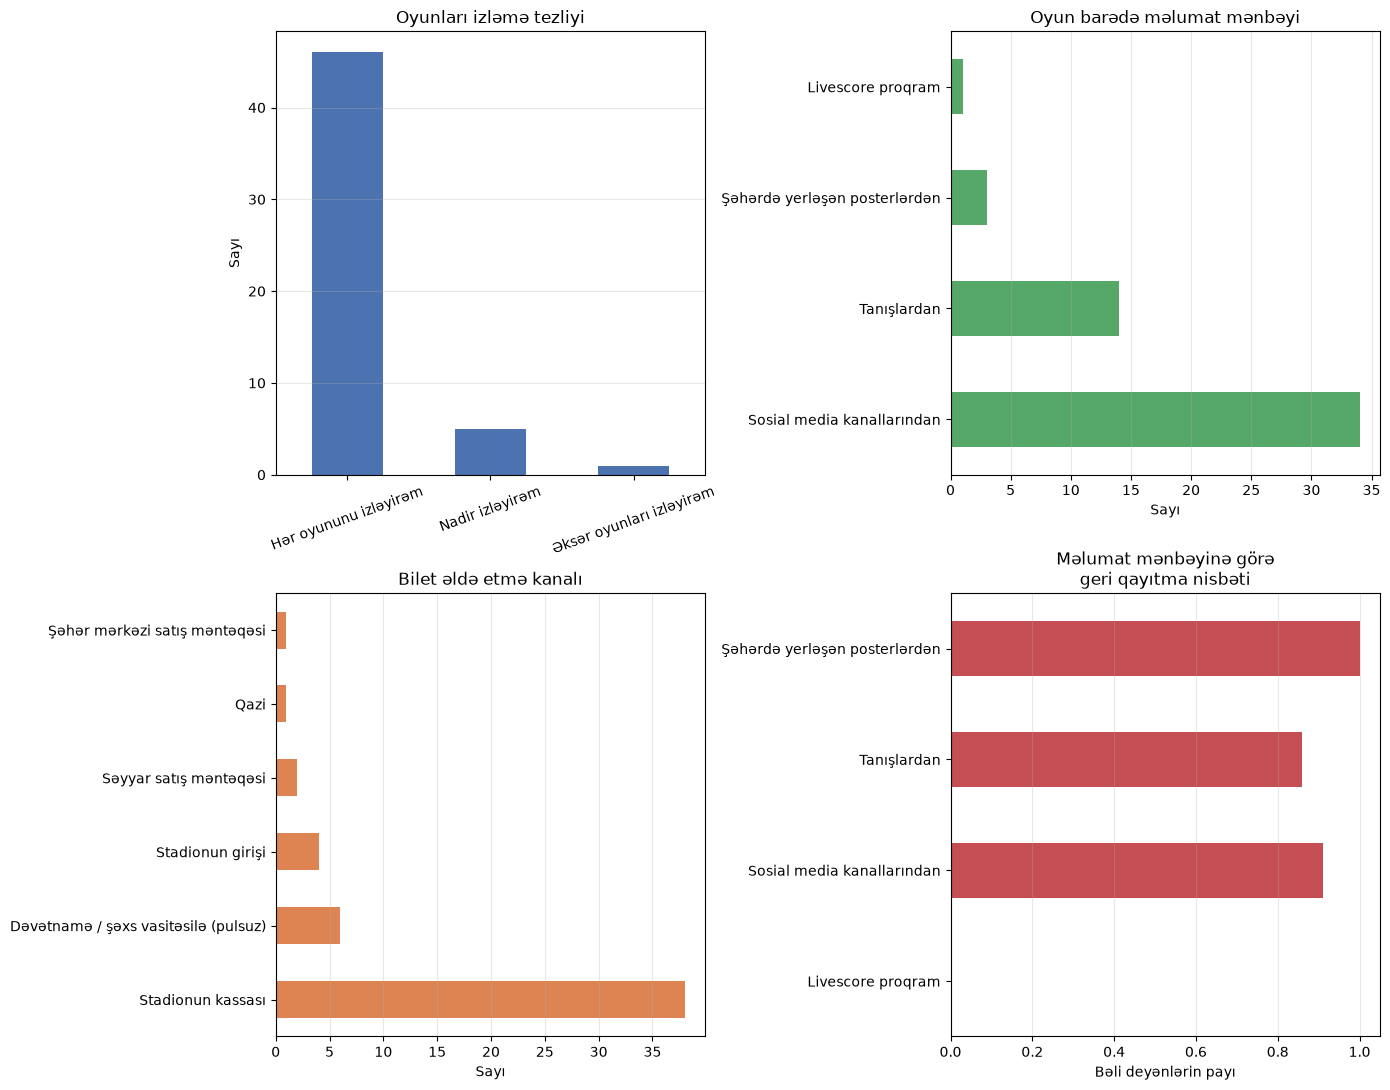

In [49]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
 
df[col_frequency].value_counts().plot(kind='bar', ax=axes[0,0], rot=20, color='#4C72B0')
axes[0,0].set_title('Oyunları izləmə tezliyi')
axes[0,0].set_xlabel('')
axes[0,0].set_ylabel('Sayı')
axes[0,0].grid(axis='y', alpha=0.3)
 
df[col_info].value_counts().plot(kind='barh', ax=axes[0,1], color='#55A868')
axes[0,1].set_title('Oyun barədə məlumat mənbəyi')
axes[0,1].set_xlabel('Sayı')
axes[0,1].set_ylabel('')
axes[0,1].grid(axis='x', alpha=0.3)
 
df['ticket_channel'].value_counts().plot(kind='barh', ax=axes[1,0], color='#DD8452')
axes[1,0].set_title('Bilet əldə etmə kanalı')
axes[1,0].set_xlabel('Sayı')
axes[1,0].set_ylabel('')
axes[1,0].grid(axis='x', alpha=0.3)
 
info_summary['geri_qayıtma_nisbəti'].plot(kind='barh', ax=axes[1,1], color='#C44E52')
axes[1,1].set_title('Məlumat mənbəyinə görə\ngeri qayıtma nisbəti')
axes[1,1].set_xlabel('Bəli deyənlərin payı')
axes[1,1].set_ylabel('')
axes[1,1].set_xlim(0, 1.05)
axes[1,1].grid(axis='x', alpha=0.3)
 
plt.tight_layout()

--------

## 8. Ailə təcrübəsi dərinliyi

Son bölmədə "oyuna ailə ilə gəlmək üçün şərait" sualını uşaqla gəlmə vəziyyəti 
və geri qayıtma niyyəti ilə əlaqələndiririk. Uşaqla və uşaqsız gələnlərin bildirdiyi 
problem növlərini müqayisə edirik ki, fərqli qrupların fərqli narahatlıqları olub-
olmadığını görək (məs. logistika problemləri vs davranış problemləri). Bu bölmədəki 
problem-müqayisəsi 4-cü bölmədə qurduğumuz `extract_problems()` whitelist 
funksiyasından təkrar istifadə edir.

In [53]:
col_family_fit = 'Sizcə, oyuna ailənizlə gəlmək üçün şərait uyğundurmu?'
col_children   = 'Stadionda son izlədiyiniz oyunu sizinlə gələnlərin arasında uşaq var idi? bir neçə uşaq gəlmişdirsə, sayı "digər" bölməsində qeyd edə bilərsiniz'
col_group_size = 'Stadionda son izlədiyiniz oyunu sizinlə neçə nəfər gəlib?'

print("=== Ailəyə uyğunluq şəraiti ===")
print(df[col_family_fit].value_counts())
print()

=== Ailəyə uyğunluq şəraiti ===
Sizcə, oyuna ailənizlə gəlmək üçün şərait uyğundurmu?
Bəli      26
Xeyr      21
Qismən     5
Name: count, dtype: int64



In [54]:
cross_fit = pd.crosstab(df[col_children], df[col_family_fit], normalize='index').round(2)
print("=== Uşaqla gəlmə vəziyyətinə görə ailəyə uyğunluq qiyməti (sətir %) ===")
print(cross_fit)
print()

=== Uşaqla gəlmə vəziyyətinə görə ailəyə uyğunluq qiyməti (sətir %) ===
Sizcə, oyuna ailənizlə gəlmək üçün şərait uyğundurmu?  Bəli  Qismən  Xeyr
Stadionda son izlədiyiniz oyunu sizinlə gələnlə...                       
Bəli                                                   0.62    0.07  0.31
Xeyr                                                   0.35    0.13  0.52



In [55]:
cross_return = pd.crosstab(df[col_family_fit], df[col_return], normalize='index').round(2)
print("=== Ailəyə uyğunluq qiymətinə görə geri qayıtma nisbəti (sətir %) ===")
print(cross_return)
print()

=== Ailəyə uyğunluq qiymətinə görə geri qayıtma nisbəti (sətir %) ===
Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?  Bəli  \
Sizcə, oyuna ailənizlə gəlmək üçün şərait uyğun...                                                              
Bəli                                                                                                     0.96   
Qismən                                                                                                   0.80   
Xeyr                                                                                                     0.81   

Son oyundakı təcrübənizə əsasən, Turan Tovuz PFK-nın növbəti oyunlarını stadionda izləmək istəyərdiniz?  Xeyr  
Sizcə, oyuna ailənizlə gəlmək üçün şərait uyğun...                                                             
Bəli                                                                                                     0.04  
Qismən                      

In [56]:
with_children = df[df[col_children] == 'Bəli']
without_children = df[df[col_children] == 'Xeyr']
 
def problem_freq_for(group):
    labels = []
    for col in problem_cols:
        for val in group[col].dropna():
            labels.extend(extract_problems(val))
    return pd.Series(labels).value_counts()
 
freq_with = problem_freq_for(with_children)
freq_without = problem_freq_for(without_children)
compare_df = pd.DataFrame({
    'Uşaqla (n=%d)' % len(with_children): freq_with,
    'Uşaqsız (n=%d)' % len(without_children): freq_without,
}).fillna(0).astype(int)
compare_df = compare_df[compare_df.sum(axis=1) > 0].sort_values(compare_df.columns[0], ascending=False)
print("=== Uşaqla / uşaqsız gələnlərin bildirdiyi problemlər ===")
print(compare_df)
print()

=== Uşaqla / uşaqsız gələnlərin bildirdiyi problemlər ===
                                               Uşaqla (n=29)  Uşaqsız (n=23)
Çıxışda sıxlıq olması                                      6               0
Avtomobil tıxacları                                        4               0
Oturacaqların çirkli olması                                4               4
Parkinq yerinin az olması                                  4               1
Tütün məhsullarının istifadəsi                             2               1
Biletdəki yerdə başqasının oturması                        2               0
Girişdə sıra/növbənin çox olması                           2               0
Partladıcı səs-küy (petard/smiçka)                         1               0
Fasilədə çıxış qapısının bağlı olması                      1               0
Butulka qapağının açıq olması (giriş qaydası)              1               0
Qadın tualetindən kişilərin istifadəsi                     1               0
Parklanma qadağası

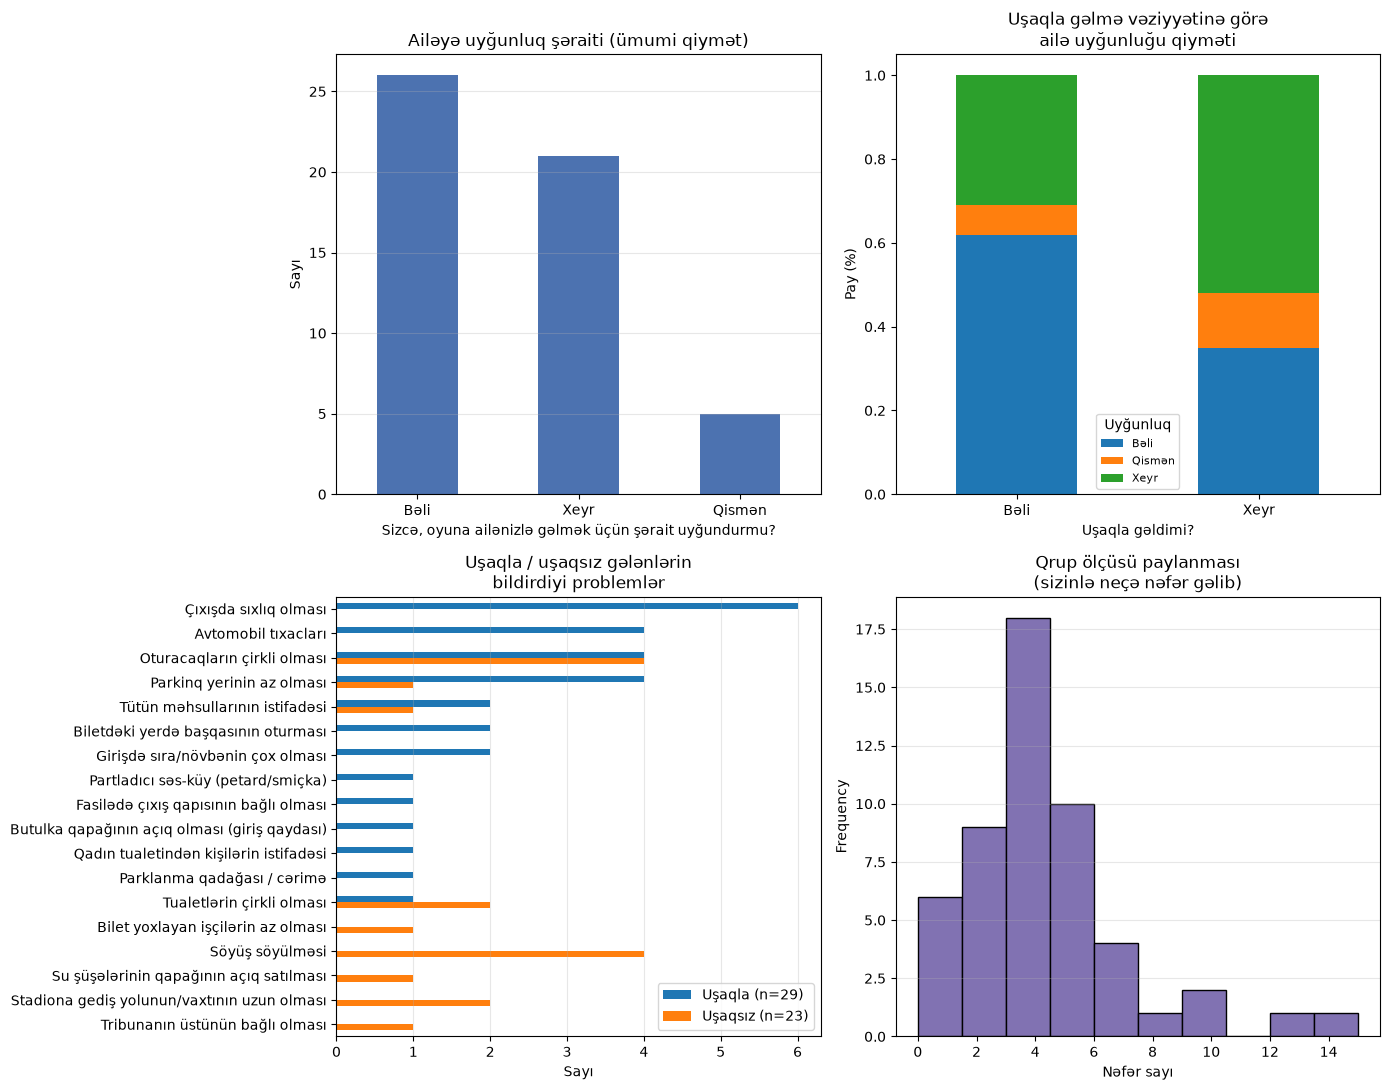

In [58]:
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
 
df[col_family_fit].value_counts().plot(kind='bar', ax=axes[0,0], rot=0, color='#4C72B0')
axes[0,0].set_title('Ailəyə uyğunluq şəraiti (ümumi qiymət)')
axes[0,0].set_ylabel('Sayı')
axes[0,0].grid(axis='y', alpha=0.3)
 
cross_fit.plot(kind='bar', ax=axes[0,1], stacked=True, rot=0)
axes[0,1].set_title('Uşaqla gəlmə vəziyyətinə görə\nailə uyğunluğu qiyməti')
axes[0,1].set_ylabel('Pay (%)')
axes[0,1].set_xlabel('Uşaqla gəldimi?')
axes[0,1].legend(fontsize=8, title='Uyğunluq')
 
compare_df.plot(kind='barh', ax=axes[1,0])
axes[1,0].set_title('Uşaqla / uşaqsız gələnlərin\nbildirdiyi problemlər')
axes[1,0].set_xlabel('Sayı')
axes[1,0].invert_yaxis()
axes[1,0].grid(axis='x', alpha=0.3)
 
df[col_group_size].plot(kind='hist', bins=10, ax=axes[1,1], color='#8172B2', edgecolor='black')
axes[1,1].set_title('Qrup ölçüsü paylanması\n(sizinlə neçə nəfər gəlib)')
axes[1,1].set_xlabel('Nəfər sayı')
axes[1,1].grid(axis='y', alpha=0.3)
 
plt.tight_layout()